In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import GroupKFold
from sklearn.model_selection import GridSearchCV
from sklearn.decomposition import PCA

from rdkit import Chem
from rdkit.Chem import MACCSkeys

from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.svm import LinearSVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor

/opt/anaconda3/envs/rdkit-env/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


# Define Functions

In [2]:
# Plotting Function
def Plot_298_T(RT_input, T_input, RT_pred, T_pred, RT_Target, T_Target, bit_matrix_298, bit_matrix_T, Save, Save_Str):
        
    fig,ax2=plt.subplot_mosaic('AB',figsize=(6.5, 3), facecolor='white')

    an_cat_labels_T = pd.DataFrame(np.concatenate(T_input), columns=bit_matrix_T.columns)
    an_cat_labels = pd.DataFrame(np.concatenate(RT_input), columns=bit_matrix_298.columns)

    ax2['A'].grid(color='gray',axis='both',alpha=0.0)
    ax2['A'].set_axisbelow(True)
    ax2['A'].tick_params(left=True, bottom=True, labelleft = True, labelbottom=True, labelsize=8)
    ax2['A'].set_facecolor('w')

    cation_colors = {
        'Ammonium': '#1F77B4',
        'Imidazolium': '#8c564b',
        'Pyrrolidinium': '#2CA02C',
        # 'Piperidinium': 'green',
        'Pyridinium': '#D62728',
        'Other': '#9467BD',
    }

    anion_shapes = {

        'Bis(sulfonyl)imide': 's',      # Square
        'Carboxylate': 'o',
        'Boroanion': 'D',    # Diamond
        'Sulfonate': '^',     # Triangle up
        'Cyanide': 'v',     # Triangle down
        'Other': 'X',    # Circle
    }

    # cation plot mapping
    cation_map = {
        'Ammonium': an_cat_labels[['0_c', '3_c']].any(axis=1),
        'Imidazolium': an_cat_labels['5_c'] == 1,
        'Pyrrolidinium': an_cat_labels['4_c'] == 1,
        #'Piperidinium': an_cat_labels['7_c'] == 1,
        'Pyridinium': an_cat_labels['8_c'] == 1,
        'Other': ~an_cat_labels[['5_c', '4_c', '8_c', '0_c', '3_c']].any(axis=1)
    }

    # anion plot mapping
    anion_map = {

        'Bis(sulfonyl)imide': an_cat_labels['37_a'] == 1,
        'Carboxylate': an_cat_labels['40_a'] == 1,
        'Boroanion': an_cat_labels['45_a'] == 1,
        'Sulfonate': an_cat_labels['38_a'] == 1,
        'Cyanide': an_cat_labels['39_a'] == 1,
        'Other': ~an_cat_labels[['37_a', '38_a', '39_a', '40_a', '45_a']].any(axis=1),
    }

    for cation, cation_mask in cation_map.items():
        for anion, anion_mask in anion_map.items():
            mask = cation_mask & anion_mask
            ax2['A'].scatter(pd.DataFrame(np.concatenate(RT_pred).ravel())[mask], 
                        pd.DataFrame(np.concatenate(RT_Target).ravel())[mask], 
                        c=cation_colors[cation], 
                        marker=anion_shapes[anion], edgecolors='k', alpha=1, s=40
                        )
            # if len(pd.DataFrame(np.concatenate(Test_Pred).ravel())[mask]) > 0:
            #     print('A', cation, anion, np.round(r2_score(pd.DataFrame(np.concatenate(Test_Target).ravel())[mask], pd.DataFrame(np.concatenate(Test_Pred).ravel())[mask]), 3), np.round(mean_squared_error(pd.DataFrame(np.concatenate(Test_Target).ravel())[mask], pd.DataFrame(np.concatenate(Test_Pred).ravel())[mask]), 3), 'n = ' + str(len(pd.DataFrame(np.concatenate(Test_Pred).ravel())[mask])))


    ax2['A'].plot([-1,6], [-1, 6], color='black')
    ax2['A'].set_xlabel('Predicted Conductivity ($\mathregular{S \cdot cm^{2} \cdot Mol^{-1}}$)',fontsize = 10)
    ax2['A'].set_ylabel('Actual Conductivity ($\mathregular{S \cdot cm^{2} \cdot Mol^{-1}}$)', fontsize = 10)
    ax2['A'].set_xlim(-0.75,5)
    ax2['A'].set_ylim(-0.25,5)
    #ax2['A'].set_title('Cation and Anion Paired Performance',fontsize = 18)

    # Manually create legend handles and labels
    legend_handles = []
    legend_labels = []

    # cations:
    for cation, color in cation_colors.items():
        handle = plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10, markeredgecolor='black')
        legend_handles.append(handle)
        legend_labels.append(cation)

    # anions:
    for anion, shape in anion_shapes.items():
        handle = plt.Line2D([0], [0], marker=shape, color='white', linestyle='None', markersize=10, markeredgecolor='black')
        legend_handles.append(handle)
        legend_labels.append(anion)

    # LEGEND???
    legend_1 = ax2['A'].legend(handles=legend_handles[:5], labels=legend_labels[:5], title='Cation Identity', alignment='left', title_fontsize=8, frameon=True, framealpha=0.0, fontsize=7, markerscale=0.6, labelspacing=0.4, handletextpad=0.1, ncol=1, columnspacing=0, loc=2)
    legend_2 = ax2['A'].legend(handles=legend_handles[5:], labels=legend_labels[5:], title='Anion Identity', alignment='right', title_fontsize=8, frameon=True, framealpha=0.0, fontsize=7, markerscale=0.6, labelspacing=0.4, handletextpad=0.1, ncol=1, columnspacing=0, loc=4, markerfirst=False)
    ax2['A'].add_artist(legend_1)    



    ax2['B'].grid(color='gray',axis='both',alpha=0.0)
    ax2['B'].set_axisbelow(True)
    ax2['B'].tick_params(left=True, bottom=True, labelleft = True, labelbottom=True, labelsize=8)
    ax2['B'].set_facecolor('w')

    cation_colors = {
        'Ammonium': '#1F77B4',
        'Imidazolium': '#8c564b',
        'Pyrrolidinium': '#2CA02C',
        # 'Piperidinium': 'green',
        'Pyridinium': '#D62728',
        'Other': '#9467BD',
    }

    anion_shapes = {

        'Bis(sulfonyl)imide': 's',      # Square
        'Carboxylate': 'o',
        'Boroanion': 'D',    # Diamond
        'Sulfonate': '^',     # Triangle up
        'Cyanide': 'v',     # Triangle down
        'Other': 'X',    # Circle
    }

    # cation plot mapping
    cation_map = {
        'Ammonium': an_cat_labels_T[['0_c', '3_c']].any(axis=1),
        'Imidazolium': an_cat_labels_T['5_c'] == 1,
        'Pyrrolidinium': an_cat_labels_T['4_c'] == 1,
        #'Piperidinium': an_cat_labels_T['7_c'] == 1,
        'Pyridinium': an_cat_labels_T['8_c'] == 1,
        'Other': ~an_cat_labels_T[['5_c', '4_c', '8_c', '0_c', '3_c']].any(axis=1)
    }

    # anion plot mapping
    anion_map = {

        'Bis(sulfonyl)imide': an_cat_labels_T['37_a'] == 1,
        'Carboxylate': an_cat_labels_T['40_a'] ==1,
        'Boroanion': an_cat_labels_T['45_a'] == 1,
        'Sulfonate': an_cat_labels_T['38_a'] == 1,
        'Cyanide': an_cat_labels_T['39_a'] == 1,
        'Other': ~an_cat_labels_T[['37_a', '38_a', '39_a', '40_a', '45_a']].any(axis=1),
    }

    for cation, cation_mask in cation_map.items():
        for anion, anion_mask in anion_map.items():
            mask = cation_mask & anion_mask
            ax2['B'].scatter(pd.DataFrame(np.concatenate(T_pred).ravel())[mask], 
                        pd.DataFrame(np.concatenate(T_Target).ravel())[mask], 
                        c=cation_colors[cation], 
                        marker=anion_shapes[anion], edgecolors='k', alpha=1, s=40
                        )
            # if len(pd.DataFrame(np.concatenate(Test_Pred_T).ravel())[mask]) > 0:
            #     print('B', cation, anion, np.round(r2_score(pd.DataFrame(np.concatenate(Test_Target_T).ravel())[mask], pd.DataFrame(np.concatenate(Test_Pred_T).ravel())[mask]), 3), np.round(mean_squared_error(pd.DataFrame(np.concatenate(Test_Target_T).ravel())[mask], pd.DataFrame(np.concatenate(Test_Pred_T).ravel())[mask]), 3), 'n = ' + str(len(pd.DataFrame(np.concatenate(Test_Pred_T).ravel())[mask])))

    ax2['B'].plot([-2, 16], [-2, 16], color='black')
    ax2['B'].set_xlabel('Predicted Conductivity ($\mathregular{S \cdot cm^{2} \cdot Mol^{-1}}$)',fontsize = 10)
    #ax2['B'].set_title('Cation and Anion Paired Performance',fontsize = 18)

    # Manually create legend handles and labels
    legend_handles = []
    legend_labels = []

    # cations:
    for cation, color in cation_colors.items():
        handle = plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10, markeredgecolor='black')
        legend_handles.append(handle)
        legend_labels.append(cation)

    # anions:
    for anion, shape in anion_shapes.items():
        handle = plt.Line2D([0], [0], marker=shape, color='white', linestyle='None', markersize=10,markeredgecolor='black')
        legend_handles.append(handle)
        legend_labels.append(anion)

    # LEGEND???
    legend_1 = ax2['B'].legend(handles=legend_handles[:5], labels=legend_labels[:5], title='Cation Identity', alignment='left', title_fontsize=8, frameon=True, framealpha=0.0, fontsize=7, markerscale=0.6, labelspacing=0.4, handletextpad=0.1, ncol=1, columnspacing=0, loc=2)
    legend_2 = ax2['B'].legend(handles=legend_handles[5:], labels=legend_labels[5:], title='Anion Identity', alignment='right', title_fontsize=8, frameon=True, framealpha=0.0, fontsize=7, markerscale=0.6, labelspacing=0.4, handletextpad=0.1, ncol=1, columnspacing=0, loc=4, markerfirst=False)
    ax2['B'].add_artist(legend_1)    
    ax2['B'].set_xticks([0,2,4,6,8,10,12,14,16])
    ax2['B'].set_ylim(-0.75,15)
    ax2['B'].set_xlim(-1.5,15)

    plt.subplots_adjust(left=0.075, right=0.975, 
                        top=0.9, bottom=0.15, 
                        wspace=0.15, hspace=0)

    # plt.subplots_adjust(left=0.05, right=0.95, 
    #                     top=0.95, bottom=0.05, 
    #                     wspace=0.05, hspace=0.05)

    if Save == True:
        plt.savefig('../Final Figures/Parity Plots/' + Save_Str + '298_T_Parity.tif', dpi=600)
        plt.savefig('../Final Figures/Parity Plots/' + Save_Str + '298_T_Parity.png', dpi=600)


    plt.show()

In [3]:
# Function to create Bit Vector of electrostatic groups
def substruct_matrix(subs_list, smiles):
    Bit_Matrix = np.zeros((len(smiles),len(subs_list)))
    count_1 = 0 
    for index, row in subs_list.iterrows():
        i = row[subs_list.columns[1]] # 'SMILES Cations/Anions:'
        j = row[subs_list.columns[2]] # 'Other representations:' (relevant resonance structures)
        count_2 = 0
        for k in smiles[smiles.columns[0]]: # iterating through each SMILES string
            mol = Chem.MolFromSmiles(k) # setting molecule for iteration
            if (mol.HasSubstructMatch(Chem.MolFromSmarts(i)) == True) | (mol.HasSubstructMatch(Chem.MolFromSmarts(j)) == True): # Checks for substructure match on either structure
                Bit_Matrix[count_2][count_1] = 1 # if match, then this position in Bit_Matrix is 1
            else:
                Bit_Matrix[count_2][count_1] = 0 # if no match, then this position in Bit_Matrix is 0
            count_2 = count_2 + 1
        count_1 = count_1 + 1
    return(Bit_Matrix)

# Import Data

In [4]:
# conductivity data 298 K
Full_data = pd.read_pickle(r"../Database['Electrical_conductivity', 'Viscosity', 'Specific_density'] With PubChem - Updated 20230720-141035.pkl")

data = Full_data[['compString',
    'Temperature',
    'molarCond_Scm2mol',
    'Viscosity',
    'Specific_density',
    'Electrical_conductivity',
    'Smiles_cation',
    'Smiles_anion',
    ]]

data = data.dropna() # dropna is used to remove/eliminate any data without info
data = data.loc[data['Temperature'] == 298] #.loc is used to find these values
data = data.drop_duplicates(subset=['Smiles_cation', 'Smiles_anion']) # drops duplicat data points
data = data.reset_index(drop=True)

molcond_scalar = StandardScaler(with_mean=False, with_std=False)
data['Normalized Cond'] = molcond_scalar.fit_transform(data['molarCond_Scm2mol'].to_numpy().reshape(-1,1))

data.loc[data['Smiles_cation'] == 'CC[NH+]1CN(C=C1)C', 'Smiles_cation'] = 'CCN1C=C[N+](=C1)C'


# conductivity data All Temp
Full_data_T = pd.read_pickle("../Database['Electrical_conductivity', 'Viscosity', 'Specific_density'] With PubChem - Updated 20230720-141035.pkl")

data_T = Full_data_T[['compString',
    'Temperature',
    'molarCond_Scm2mol',
    'Viscosity',
    'Specific_density',
    'Electrical_conductivity',
    'Smiles_cation',
    'Smiles_anion',
    ]]

data_T = data_T.copy().dropna() # dropna is used to remove/eliminate any data without info
data_T = data_T.drop_duplicates(subset=['Smiles_cation', 'Smiles_anion', 'Temperature']) # drops duplicat data points
data_T = data_T.reset_index(drop=True)

molcond_scalar_T = StandardScaler(with_mean=False, with_std=False)
data_T['Normalized Cond'] = molcond_scalar_T.fit_transform(data_T['molarCond_Scm2mol'].to_numpy().reshape(-1,1))

data_T = data[['compString']].merge(data_T, on=['compString'], how='left').drop_duplicates(subset=['Smiles_cation', 'Smiles_anion', 'Temperature'])

data_T.loc[data_T['Smiles_cation'] == 'CC[NH+]1CN(C=C1)C', 'Smiles_cation'] = 'CCN1C=C[N+](=C1)C'

# data_T['Temperature'] = data_T['Temperature']

# Create SMARTS Representation

In [5]:
# Electrostatic groups Bit Matrix

cations = data[['Smiles_cation']] # note: leaving off drop.duplicates here and for anions
anions = data[['Smiles_anion']]
subs_list = pd.read_csv(r"../IL.SMARTS_4.3.csv",dtype='str',na_values='',na_filter=False) # electrostatic SMARTS strings

Bit_Matrix_Cat = pd.DataFrame(substruct_matrix(subs_list,cations))
Bit_Matrix_An = pd.DataFrame(substruct_matrix(subs_list,anions))

Bit_Matrix_Cat.columns = [str(i) + '_c' for i in (np.arange(0,subs_list.shape[0],1))]
Bit_Matrix_An.columns = [str(i) + '_a' for i in (np.arange(0,subs_list.shape[0],1))]

# Bit Matrix containing + and - electrostatic groups
Bit_Matrix_ES_df = pd.concat([pd.DataFrame(Bit_Matrix_Cat, columns=[str(i) + '_c' for i in (np.arange(0,subs_list.shape[0],1))], index=np.arange(0,182,1)), pd.DataFrame(Bit_Matrix_An, columns=[str(i) + '_a' for i in (np.arange(0,subs_list.shape[0],1))],  index=np.arange(0,182,1))],axis=1, join='inner')
Bit_Matrix_Short = Bit_Matrix_ES_df.loc[:, ((Bit_Matrix_ES_df.sum(axis=0) > 3) & (Bit_Matrix_ES_df.sum(axis=0) < 180))]#.merge(Bit_Matrix_ES_df.loc[:,'7_c'], left_index=True, right_index=True)

cat_subs = subs_list.copy()
an_subs = subs_list.copy()

cat_subs[['Name_clean']] = cat_subs[['Name:']]
an_subs[['Name_clean']] = ' ' + an_subs[['Name:']]

cat_subs[['Name:']] = cat_subs[['Name:']] + str('_c')
an_subs[['Name:']] = an_subs[['Name:']] + str('_a')

cat_subs[['Ion']] = 0
an_subs[['Ion']] = 1

subs = pd.concat((cat_subs, an_subs)).reset_index(drop=True)

Bit_index = Bit_Matrix_ES_df.T.reset_index(drop=True)
Names_df = subs.loc[(Bit_index.sum(axis=1) > 3) & (Bit_index.sum(axis=1) < 180)]#.merge(subs.iloc[7:8], on=['Name:', 'SMARTS:', 'Other representations:', 'Name_clean', 'Ion'], how='outer')

# Electrostatic groups Bit Matrix

cations_T = data_T[['Smiles_cation']] # note: leaving off drop.duplicates here and for anions
anions_T = data_T[['Smiles_anion']]
subs_list_T = pd.read_csv(r"../IL.SMARTS_4.3.csv",dtype='str',na_values='',na_filter=False) # electrostatic SMARTS strings

Bit_Matrix_Cat_T = pd.DataFrame(substruct_matrix(subs_list_T,cations_T))
Bit_Matrix_An_T = pd.DataFrame(substruct_matrix(subs_list_T,anions_T))

Bit_Matrix_Cat_T.columns = [str(i) + '_c' for i in (np.arange(0,subs_list_T.shape[0],1))]
Bit_Matrix_An_T.columns = [str(i) + '_a' for i in (np.arange(0,subs_list_T.shape[0],1))]

# Bit Matrix containing + and - electrostatic groups
Bit_Matrix_ES_df_T = pd.concat([pd.DataFrame(Bit_Matrix_Cat_T, columns=[str(i) + '_c' for i in (np.arange(0,subs_list_T.shape[0],1))], index=np.arange(0,data_T.shape[0],1)), pd.DataFrame(Bit_Matrix_An_T, columns=[str(i) + '_a' for i in (np.arange(0,subs_list_T.shape[0],1))],  index=np.arange(0,data_T.shape[0],1))],axis=1, join='inner')
Bit_Matrix_Short_Ta = Bit_Matrix_ES_df_T.loc[:, ((Bit_Matrix_ES_df.sum(axis=0) > 3) & (Bit_Matrix_ES_df.sum(axis=0) < 180))]
#Bit_Matrix_Short_Ta = Bit_Matrix_ES_df_T.loc[:, ((Bit_Matrix_ES_df_T.sum(axis=0) > 10) & (Bit_Matrix_ES_df_T.sum(axis=0) < 1800))]


scaleT = StandardScaler()
Bit_Matrix_Short_T = pd.concat([Bit_Matrix_Short_Ta, pd.DataFrame(scaleT.fit_transform(data_T[['Temperature']]), columns=['T'])],axis=1, join='inner')

cat_subs_T = subs_list_T.copy()
an_subs_T = subs_list_T.copy()

cat_subs_T[['Name_clean']] = cat_subs_T[['Name:']]
an_subs_T[['Name_clean']] = ' ' + an_subs_T[['Name:']]

cat_subs_T[['Name:']] = cat_subs_T[['Name:']] + str('_c')
an_subs_T[['Name:']] = an_subs_T[['Name:']] + str('_a')

cat_subs_T[['Ion']] = 0
an_subs_T[['Ion']] = 1

subs_T = pd.concat((cat_subs_T, an_subs_T)).reset_index(drop=True)

Bit_index_T = Bit_Matrix_ES_df.T.reset_index(drop=True)
#Names_df_T = subs_T.loc[(Bit_index.sum(axis=1) > 3) & (Bit_index.sum(axis=1) < 180)]#.merge(subs_T.iloc[7:8], on=['Name:', 'SMARTS:', 'Other representations:', 'Name_clean', 'Ion'], how='outer')
#Names_df_T = subs_T.loc[:, ((Bit_Matrix_ES_df_T.sum(axis=0) > 10) & (Bit_Matrix_ES_df_T.sum(axis=0) < 1800))]
#Names_df_T.loc[Names_df_T.shape[0]+1] = ['Temperature', '', '','', 2]

# Create MACCS Representations

In [6]:
cations = data[['Smiles_cation']] # note: leaving off drop.duplicates here and for anions
anions = data[['Smiles_anion']]

smiles_a = list(data['Smiles_anion'])
smi_a=[Chem.MolFromSmiles(x) for x in smiles_a]
fps_a =  [MACCSkeys.GenMACCSKeys(x) for x in smi_a] # In this example I'll use MACCSKeys

smiles_c = list(data['Smiles_cation'])
smi_c=[Chem.MolFromSmiles(x) for x in smiles_c]
fps_c =  [MACCSkeys.GenMACCSKeys(x) for x in smi_c] # In this example I'll use MACCSKeys

anion_fps = np.array([[0]*167]*len(fps_a))
cation_fps = np.array([[0]*167]*len(fps_c))

for i in range(len(fps_a)):
    for j in range (0,167):
        anion_fps[i][j] = int(fps_a[i][j])

for i in range(len(fps_c)):
    for j in range (0,167):
        cation_fps[i][j] = int(fps_c[i][j])

Cation_maccs_df = pd.DataFrame(cation_fps)
Anion_maccs_df = pd.DataFrame(anion_fps)

Bit_Matrix_MACCS_df = pd.concat((Cation_maccs_df, Anion_maccs_df), axis=1, join='inner')

Bit_Matrix_MACCS_Short = Bit_Matrix_MACCS_df.loc[:, ((Bit_Matrix_MACCS_df.sum(axis=0) > 3) & (Bit_Matrix_MACCS_df.sum(axis=0) < 180))]


cat_subs = subs_list.copy()
an_subs = subs_list.copy()

cat_subs[['Name_clean']] = cat_subs[['Name:']]
an_subs[['Name_clean']] = ' ' + an_subs[['Name:']]

cat_subs[['Name:']] = cat_subs[['Name:']] + str('_c')
an_subs[['Name:']] = an_subs[['Name:']] + str('_a')

cat_subs[['Ion']] = 0
an_subs[['Ion']] = 1

subs = pd.concat((cat_subs, an_subs)).reset_index(drop=True)

#Bit_index = Bit_Matrix_MACCS_df.T.reset_index(drop=True)
#Names_df = subs.loc[(Bit_index.sum(axis=1) > 3) & (Bit_index.sum(axis=1) < 180)]#.merge(subs.iloc[7:8], on=['Name:', 'SMARTS:', 'Other representations:', 'Name_clean', 'Ion'], how='outer')

pca = PCA(n_components=36)
Bit_Matrix_MACCS_Short_PCA = pd.DataFrame(data=pca.fit_transform(Bit_Matrix_MACCS_Short.to_numpy()))




# Electrostatic groups Bit Matrix

cations_T = data_T[['Smiles_cation']] # note: leaving off drop.duplicates here and for anions
anions_T = data_T[['Smiles_anion']]

smiles_T_a = list(data_T['Smiles_anion'])
smi_T_a=[Chem.MolFromSmiles(x) for x in smiles_T_a]
fps_T_a =  [MACCSkeys.GenMACCSKeys(x) for x in smi_T_a] # In this example I'll use MACCSKeys

smiles_T_c = list(data_T['Smiles_cation'])
smi_T_c=[Chem.MolFromSmiles(x) for x in smiles_T_c]
fps_T_c =  [MACCSkeys.GenMACCSKeys(x) for x in smi_T_c] # In this example I'll use MACCSKeys

anion_fps_T = np.array([[0]*167]*len(fps_T_a))
cation_fps_T = np.array([[0]*167]*len(fps_T_c))

for i in range(len(fps_T_a)):
    for j in range (0,167):
        anion_fps_T[i][j] = int(fps_T_a[i][j])

for i in range(len(fps_T_c)):
    for j in range (0,167):
        cation_fps_T[i][j] = int(fps_T_c[i][j])

Cation_maccs_df_T = pd.DataFrame(cation_fps_T)
Anion_maccs_df_T = pd.DataFrame(anion_fps_T)

Bit_Matrix_MACCS_df_T = pd.concat((Cation_maccs_df_T, Anion_maccs_df_T), axis=1, join='inner')


Bit_Matrix_MACCS_Short_Ta = Bit_Matrix_MACCS_df_T.loc[:, ((Bit_Matrix_MACCS_df.sum(axis=0) > 3) & (Bit_Matrix_MACCS_df.sum(axis=0) < 180))]


pca_t = PCA(n_components=36)
Bit_Matrix_MACCS_df_T_PCA = pd.DataFrame(data=pca_t.fit_transform(Bit_Matrix_MACCS_Short_Ta.to_numpy()))


scaleT = StandardScaler()

Bit_Matrix_MACCS_Short_T = pd.concat([Bit_Matrix_MACCS_Short_Ta, pd.DataFrame(scaleT.fit_transform(data_T[['Temperature']]))],axis=1, join='inner')
Bit_Matrix_MACCS_Short_T_PCA = pd.concat([Bit_Matrix_MACCS_df_T_PCA, pd.DataFrame(scaleT.fit_transform(data_T[['Temperature']]))],axis=1, join='inner')


# Regressions

/opt/anaconda3/envs/rdkit-env/lib/python3.9/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/anaconda3/envs/rdkit-env/lib/python3.9/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/anaconda3/envs/rdkit-env/lib/python3.9/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/anaconda3/envs/rdkit-env/lib/python3.9/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/anaconda3/envs/rdkit-env/lib/python3.9/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/anaconda3/envs/rdkit-env/lib/python3.9/site-packages/sklearn

SMARTS Linear_ 298 K Best Parameters: {'C': 1} ; Test R2=0.563 ; Test RMSE=0.529 ; Train R2=0.711 ; Train RMSE=0.43
SMARTS Linear_ All Temp Best Parameters: {'C': 1} ; Test R2=0.635 ; Test RMSE=1.167 ; R2=0.721 ; RMSE=1.019


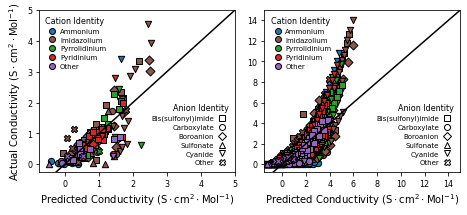

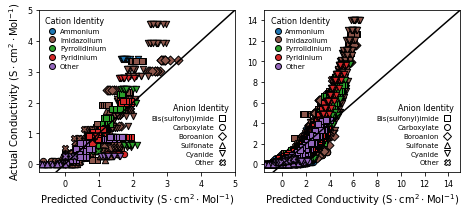

SMARTS RBF_Kernel_ 298 K Best Parameters: {'C': 10} ; Test R2=0.764 ; Test RMSE=0.388 ; Train R2=0.97 ; Train RMSE=0.139
SMARTS RBF_Kernel_ All Temp Best Parameters: {'C': 1000} ; Test R2=0.838 ; Test RMSE=0.778 ; R2=0.979 ; RMSE=0.278


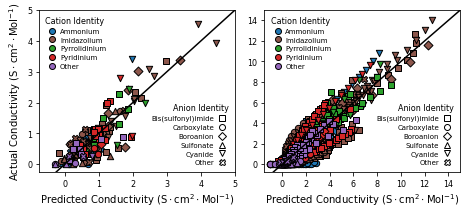

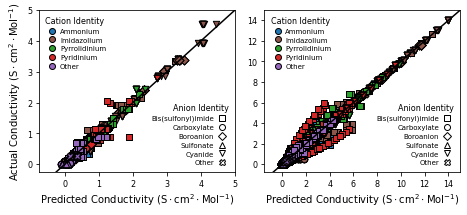

SMARTS Random_Forest_ 298 K Best Parameters: {'max_depth': 200} ; Test R2=0.667 ; Test RMSE=0.462 ; Train R2=0.935 ; Train RMSE=0.203
SMARTS Random_Forest_ All Temp Best Parameters: {'max_depth': 10} ; Test R2=0.787 ; Test RMSE=0.89 ; R2=0.966 ; RMSE=0.356


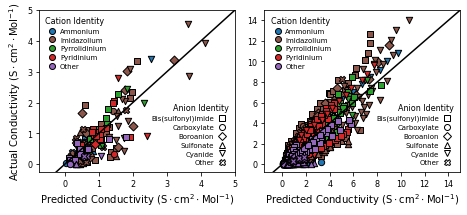

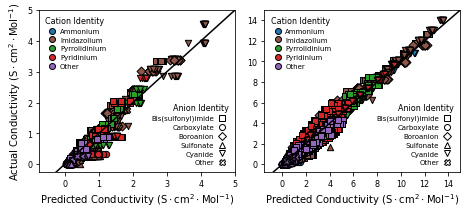

SMARTS Neural_Network_ 298 K Best Parameters: {'activation': 'relu', 'hidden_layer_sizes': (100, 100, 100)} ; Test R2=0.82 ; Test RMSE=0.34 ; Train R2=0.98 ; Train RMSE=0.113
SMARTS Neural_Network_ All Temp Best Parameters: {'activation': 'relu', 'hidden_layer_sizes': (200, 200, 200)} ; Test R2=0.848 ; Test RMSE=0.751 ; R2=0.973 ; RMSE=0.318


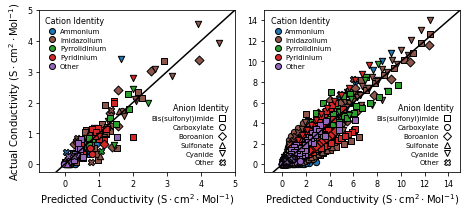

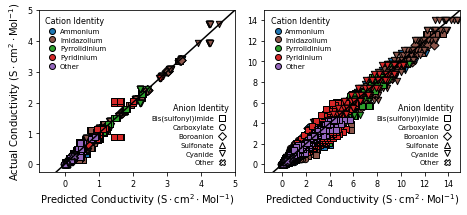

/opt/anaconda3/envs/rdkit-env/lib/python3.9/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/anaconda3/envs/rdkit-env/lib/python3.9/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/anaconda3/envs/rdkit-env/lib/python3.9/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/anaconda3/envs/rdkit-env/lib/python3.9/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/anaconda3/envs/rdkit-env/lib/python3.9/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/anaconda3/envs/rdkit-env/lib/python3.9/site-packages/sklearn

MACCS Linear_ 298 K Best Parameters: {'C': 0.1} ; Test R2=0.516 ; Test RMSE=0.557 ; Train R2=0.664 ; Train RMSE=0.464
MACCS Linear_ All Temp Best Parameters: {'C': 0.1} ; Test R2=0.67 ; Test RMSE=1.109 ; R2=0.768 ; RMSE=0.93


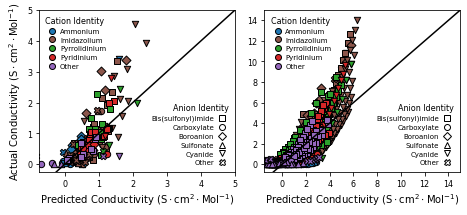

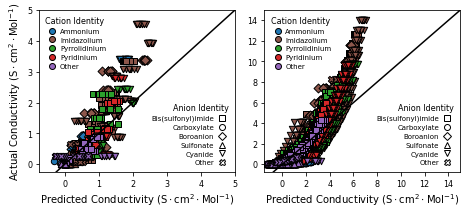

MACCS RBF_Kernel_ 298 K Best Parameters: {'C': 1000} ; Test R2=0.733 ; Test RMSE=0.414 ; Train R2=0.981 ; Train RMSE=0.112
MACCS RBF_Kernel_ All Temp Best Parameters: {'C': 1000} ; Test R2=0.863 ; Test RMSE=0.715 ; R2=0.995 ; RMSE=0.143


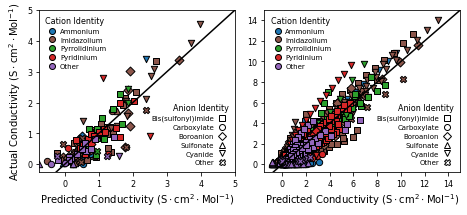

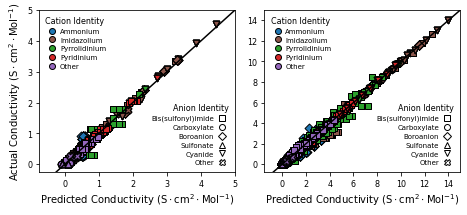

MACCS Random_Forest_ 298 K Best Parameters: {'max_depth': 25} ; Test R2=0.62 ; Test RMSE=0.493 ; Train R2=0.934 ; Train RMSE=0.206
MACCS Random_Forest_ All Temp Best Parameters: {'max_depth': 300} ; Test R2=0.784 ; Test RMSE=0.897 ; R2=0.992 ; RMSE=0.176


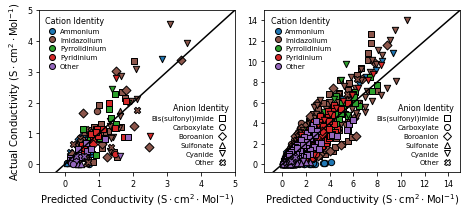

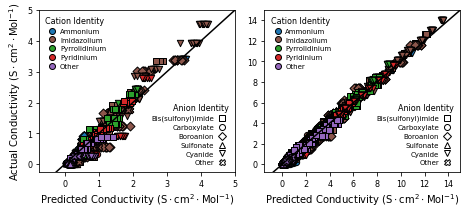

MACCS Neural_Network_ 298 K Best Parameters: {'activation': 'relu', 'hidden_layer_sizes': (200, 200, 200)} ; Test R2=0.83 ; Test RMSE=0.33 ; Train R2=0.982 ; Train RMSE=0.107
MACCS Neural_Network_ All Temp Best Parameters: {'activation': 'tanh', 'hidden_layer_sizes': (200, 200, 200)} ; Test R2=0.888 ; Test RMSE=0.647 ; R2=0.978 ; RMSE=0.288


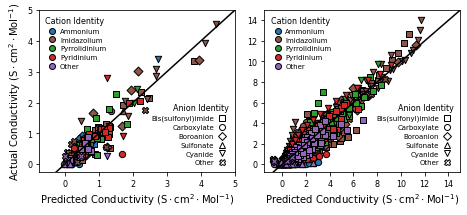

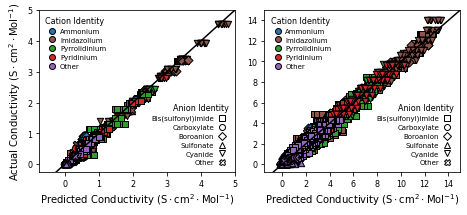

/opt/anaconda3/envs/rdkit-env/lib/python3.9/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/anaconda3/envs/rdkit-env/lib/python3.9/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/anaconda3/envs/rdkit-env/lib/python3.9/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/anaconda3/envs/rdkit-env/lib/python3.9/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/anaconda3/envs/rdkit-env/lib/python3.9/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/anaconda3/envs/rdkit-env/lib/python3.9/site-packages/sklearn

MACCS_PCA Linear_ 298 K Best Parameters: {'C': 0.1} ; Test R2=0.432 ; Test RMSE=0.603 ; Train R2=0.579 ; Train RMSE=0.519
MACCS_PCA Linear_ All Temp Best Parameters: {'C': 0.1} ; Test R2=0.639 ; Test RMSE=1.16 ; R2=0.739 ; RMSE=0.986


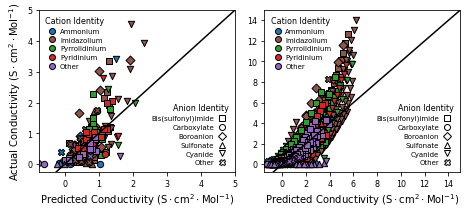

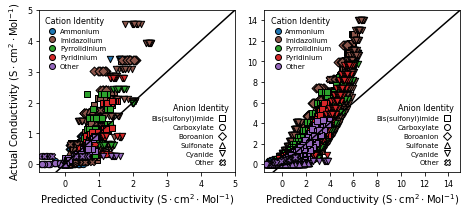

MACCS_PCA RBF_Kernel_ 298 K Best Parameters: {'C': 10} ; Test R2=0.69 ; Test RMSE=0.445 ; Train R2=0.95 ; Train RMSE=0.179
MACCS_PCA RBF_Kernel_ All Temp Best Parameters: {'C': 10} ; Test R2=0.838 ; Test RMSE=0.777 ; R2=0.988 ; RMSE=0.209


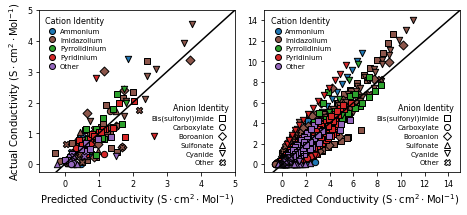

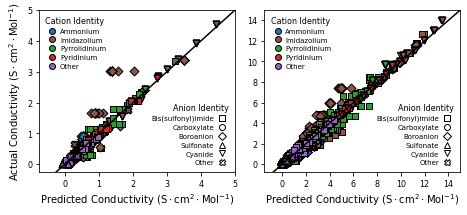

MACCS_PCA Random_Forest_ 298 K Best Parameters: {'max_depth': 25} ; Test R2=0.435 ; Test RMSE=0.602 ; Train R2=0.912 ; Train RMSE=0.237
MACCS_PCA Random_Forest_ All Temp Best Parameters: {'max_depth': 1000} ; Test R2=0.642 ; Test RMSE=1.155 ; R2=0.994 ; RMSE=0.154


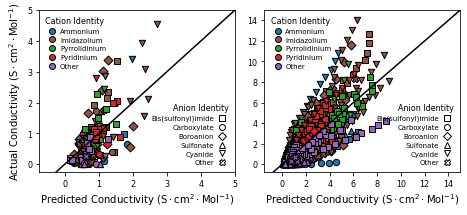

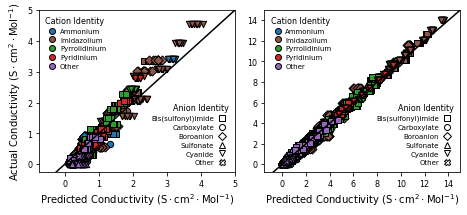

MACCS_PCA Neural_Network_ 298 K Best Parameters: {'activation': 'relu', 'hidden_layer_sizes': (100, 100, 100)} ; Test R2=0.678 ; Test RMSE=0.454 ; Train R2=0.988 ; Train RMSE=0.088
MACCS_PCA Neural_Network_ All Temp Best Parameters: {'activation': 'relu', 'hidden_layer_sizes': (100, 100, 100)} ; Test R2=0.863 ; Test RMSE=0.715 ; R2=0.985 ; RMSE=0.235


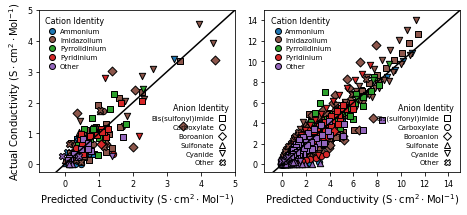

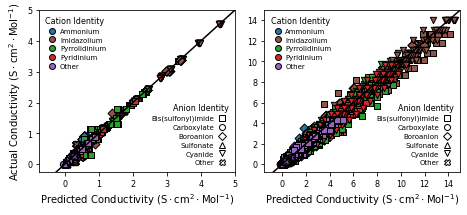

In [7]:
seed = 0

Representations = ['0']*3

Representations[0] = 'SMARTS'
Representations[1] = 'MACCS'
Representations[2] = 'MACCS_PCA'

for Rep in Representations:

    if Rep == 'SMARTS':
        X = Bit_Matrix_Short
        y = data[['Normalized Cond']]

        X_T = Bit_Matrix_Short_T
        y_T = data_T[['Normalized Cond']]

    if Rep == 'MACCS':
        X = Bit_Matrix_MACCS_Short
        y = data[['Normalized Cond']]

        X_T = Bit_Matrix_MACCS_Short_T
        y_T = data_T[['Normalized Cond']]

    if Rep == 'MACCS_PCA':
        X = Bit_Matrix_MACCS_Short_PCA
        y = data[['Normalized Cond']]

        X_T = Bit_Matrix_MACCS_Short_T_PCA
        y_T = data_T[['Normalized Cond']]

    k_fold = int(10)

    train_indices = [0.0]*k_fold
    test_indices = [0.0]*k_fold

    Train_Input = [[]]*k_fold
    Train_Input_ID = [[]]*k_fold
    Train_Target = [[]]*k_fold
    Test_Input = [[]]*k_fold
    Test_Input_ID = [[]]*k_fold
    Test_Target = [[]]*k_fold
    Test_CompStrings = [[]]*k_fold
    Test_NernstEinstein = [[]]*k_fold

    train_indices_T = [0.0]*k_fold
    test_indices_T = [0.0]*k_fold

    Train_Input_T = [[]]*k_fold
    Train_Input_ID_T = [[]]*k_fold
    Train_Target_T = [[]]*k_fold
    Test_Input_T = [[]]*k_fold
    Test_Input_ID_T = [[]]*k_fold
    Test_Target_T = [[]]*k_fold
    Train_CompStrings_T = [[]]*k_fold
    Test_CompStrings_T = [[]]*k_fold
    Test_NernstEinstein_T = [[]]*k_fold
    Test_Temperature_T = [[]]*k_fold

    i = 0
    gss = GroupKFold(n_splits=k_fold, shuffle=True, random_state=seed)

    for train_idx, test_idx in gss.split(X, y, data['compString']):
        train_indices[i] = train_idx
        test_indices[i] = test_idx

        Train_Input[i] = X.iloc[train_indices[i].tolist(),:].values
        Train_Input_ID[i] = Bit_Matrix_Short.iloc[train_indices[i].tolist(),:].values
        Train_Target[i] = y.iloc[train_indices[i].tolist(),:].values

        Test_Input[i] = X.iloc[test_indices[i].tolist(),:].values
        Test_Input_ID[i] = Bit_Matrix_Short.iloc[test_indices[i].tolist(),:].values
        Test_Target[i] = y.iloc[test_indices[i].tolist(),:].values
        Test_CompStrings[i] = data[['compString']].iloc[test_indices[i].tolist(),:].values
        i += 1

    i = 0
    gss_T = GroupKFold(n_splits=k_fold, shuffle=True, random_state=seed)

    for train_idx, test_idx in gss_T.split(X_T, y_T, data_T['compString']):
        train_indices_T[i] = train_idx
        test_indices_T[i] = test_idx

        Train_Input_T[i] = X_T.iloc[train_indices_T[i].tolist(),:].values
        Train_Input_ID_T[i] = Bit_Matrix_Short_T.iloc[train_indices_T[i].tolist(),:].values
        Train_Target_T[i] = y_T.iloc[train_indices_T[i].tolist(),:].values

        Test_Input_T[i] = X_T.iloc[test_indices_T[i].tolist(),:].values
        Test_Input_ID_T[i] = Bit_Matrix_Short_T.iloc[test_indices_T[i].tolist(),:].values
        Test_Target_T[i] = y_T.iloc[test_indices_T[i].tolist(),:].values
        Test_CompStrings_T[i] = data_T[['compString']].iloc[test_indices_T[i].tolist(),:].values
        Train_CompStrings_T[i] = data_T[['compString']].iloc[train_indices_T[i].tolist(),:].values
        Test_Temperature_T[i] = data_T[['Temperature']].iloc[test_indices_T[i].tolist(),:].values
        i += 1

    Regressions = [0]*4
    Reg_kwargs =  ['0']*4
    Regressions[0], Reg_kwargs[0] = LinearSVR(), {'C':[ 0.000001, 0.00001, 0.0001, 0.001,0.01,0.1,1,10,100,1000,10000,100000,1000000]}
    Regressions[1], Reg_kwargs[1] = SVR(kernel='rbf',C=10, epsilon=0.1), {'C':[ 0.000001, 0.00001, 0.0001, 0.001,0.01,0.1,1,10,100,1000,10000,100000,1000000]}
    Regressions[2], Reg_kwargs[2] = RandomForestRegressor(n_estimators=100,max_depth=200,bootstrap=True), {'max_depth':[5,10,25,50,100,200,300,500,1000]}
    Regressions[3], Reg_kwargs[3] = MLPRegressor(activation='relu', epsilon=1e-8, hidden_layer_sizes=(16, 8, 4, 2), alpha=0.001, random_state=0, learning_rate_init=0.01, max_iter=10000), {'hidden_layer_sizes':[ (200,200,200), (100,100,100,100), (100,100,100), (100,100), (100)], 'activation':['relu','tanh']}

    Regressions_T = [0]*4
    Reg_kwargs_T =  ['0']*4
    Regressions_T[0], Reg_kwargs_T[0] = LinearSVR(), {'C':[0.1,1,10,100,1000]}
    Regressions_T[1], Reg_kwargs_T[1] = SVR(kernel='rbf',C=10, epsilon=1), {'C':[1, 10,100,1000]}
    Regressions_T[2], Reg_kwargs_T[2] = RandomForestRegressor(n_estimators=100,max_depth=200,bootstrap=True), {'max_depth':[5,10,25,50,100,200,300,500,1000]}
    Regressions_T[3], Reg_kwargs_T[3] = MLPRegressor(activation='relu', epsilon=1e-8, hidden_layer_sizes=(16, 8, 4, 2), alpha=0.001, random_state=0, learning_rate_init=0.01, max_iter=10000), {'hidden_layer_sizes':[ (200,200,200), (100,100,100,100), (100,100,100), (100,100), (100)], 'activation':['relu','tanh']}


    for j in range(4):
        gscv = GridSearchCV(Regressions[j], Reg_kwargs[j], scoring='neg_root_mean_squared_error', cv=GroupKFold(n_splits=k_fold, shuffle=True, random_state=seed))
        gscv.fit(X, y.to_numpy().ravel(), groups=data['compString'])

        best_kwargs = pd.DataFrame(gscv.cv_results_).sort_values(by='rank_test_score', ascending=True)[['params', 'mean_test_score', 'rank_test_score']].iloc[0]['params']
        if j == 0:
            Regressor = LinearSVR(**best_kwargs)
            save_name = 'Linear_'
        elif j == 1:
            Regressor = SVR(epsilon=0.1, **best_kwargs)    
            save_name = 'RBF_Kernel_'    
        elif j == 2: 
            Regressor = RandomForestRegressor(n_estimators=100,bootstrap=True, **best_kwargs)   
            save_name = 'Random_Forest_'
        elif j == 3:
            Regressor = MLPRegressor(epsilon=1e-8, alpha=0.001, random_state=0, learning_rate_init=0.01, max_iter=10000, **best_kwargs)   
            save_name = 'Neural_Network_'

        Train_Pred = [[]]*k_fold
        Test_Pred = [[]]*k_fold
        Train_r2 = [0.0]*k_fold
        Test_r2 = [0.0]*k_fold
        Train_mse = [0.0]*k_fold
        Test_mse = [0.0]*k_fold

        for tset in range(0,k_fold):

            # Training set
            Regressor.fit(Train_Input[tset], Train_Target[tset].reshape(Train_Target[tset].shape[0],)) 
            Train_Pred[tset] = Regressor.predict(Train_Input[tset]) # training predicted condc
            Test_Pred[tset] = Regressor.predict(Test_Input[tset]) # test predicted cond
            Train_r2[tset] = r2_score(Train_Target[tset], Train_Pred[tset]) # r^2 score, training
            Test_r2[tset] = r2_score(Test_Target[tset], Test_Pred[tset]) # r^2 score, testing
            Train_mse[tset] = mean_squared_error(Train_Target[tset], Train_Pred[tset]) # r^2 score, training
            Test_mse[tset] = mean_squared_error(Test_Target[tset], Test_Pred[tset]) # r^2 score, testing

        gscv_T = GridSearchCV(Regressions_T[j], Reg_kwargs_T[j], scoring='neg_root_mean_squared_error', cv=GroupKFold(n_splits=k_fold, shuffle=True, random_state=seed))
        gscv_T.fit(X_T, y_T.to_numpy().ravel(), groups=data_T['compString'])

        best_kwargs_T = pd.DataFrame(gscv_T.cv_results_).sort_values(by='rank_test_score', ascending=True)[['params', 'mean_test_score', 'rank_test_score']].iloc[0]['params']
        if j == 0:
            Regressor_T = LinearSVR(**best_kwargs_T)
        elif j == 1:
            Regressor_T = SVR(epsilon=0.1, **best_kwargs_T)        
        elif j == 2:
            Regressor_T = RandomForestRegressor(n_estimators=100,bootstrap=True, **best_kwargs_T)   
        elif j == 3:
            Regressor_T = MLPRegressor(epsilon=1e-8, alpha=0.001, random_state=0, learning_rate_init=0.01, max_iter=10000, **best_kwargs_T)   
                
        Train_Pred_T = [[]]*k_fold
        Test_Pred_T = [[]]*k_fold
        Train_r2_T = [0.0]*k_fold
        Test_r2_T = [0.0]*k_fold
        Train_mse_T = [0.0]*k_fold
        Test_mse_T = [0.0]*k_fold

        for tset in range(0,k_fold):
            # Training set
            Regressor_T.fit(Train_Input_T[tset], Train_Target_T[tset].reshape(Train_Target_T[tset].shape[0],)) 
            Train_Pred_T[tset] = Regressor_T.predict(Train_Input_T[tset]) # training predicted condc
            Test_Pred_T[tset] = Regressor_T.predict(Test_Input_T[tset]) # test predicted cond
            Train_r2_T[tset] = r2_score(Train_Target_T[tset], Train_Pred_T[tset]) # r^2 score, training
            Test_r2_T[tset] = r2_score(Test_Target_T[tset], Test_Pred_T[tset]) # r^2 score, testing
            Train_mse_T[tset] = mean_squared_error(Train_Target_T[tset], Train_Pred_T[tset]) # r^2 score, training
            Test_mse_T[tset] = mean_squared_error(Test_Target_T[tset], Test_Pred_T[tset]) # r^2 score, testing

        print(Rep, save_name, '298 K Best Parameters:', best_kwargs, 
              '; Test R2='+str(np.round(r2_score(np.concatenate(Test_Target), np.concatenate(Test_Pred)), 3)), 
              '; Test RMSE='+str(np.round(np.sqrt(mean_squared_error(np.concatenate(Test_Target), np.concatenate(Test_Pred))), 3)),
              '; Train R2='+str(np.round(r2_score(np.concatenate(Train_Target), np.concatenate(Train_Pred)), 3)), 
              '; Train RMSE='+str(np.round(np.sqrt(mean_squared_error(np.concatenate(Train_Target), np.concatenate(Train_Pred))), 3))
              )
        print(Rep, save_name, 'All Temp Best Parameters:', best_kwargs_T, 
              '; Test R2='+str(np.round(r2_score(np.concatenate(Test_Target_T), np.concatenate(Test_Pred_T)), 3)), 
              '; Test RMSE='+str(np.round(np.sqrt(mean_squared_error(np.concatenate(Test_Target_T), np.concatenate(Test_Pred_T))), 3)),
              '; R2='+str(np.round(r2_score(np.concatenate(Train_Target_T), np.concatenate(Train_Pred_T)), 3)), 
              '; RMSE='+str(np.round(np.sqrt(mean_squared_error(np.concatenate(Train_Target_T), np.concatenate(Train_Pred_T))), 3))
              )

        Plot_298_T(Test_Input_ID, Test_Input_ID_T, Test_Pred, Test_Pred_T, Test_Target, Test_Target_T, Bit_Matrix_Short, Bit_Matrix_Short_T, True, Rep + '_' + save_name + 'Test_')
        Plot_298_T(Train_Input_ID, Train_Input_ID_T, Train_Pred, Train_Pred_T, Train_Target, Train_Target_T, Bit_Matrix_Short, Bit_Matrix_Short_T, True, Rep + '_' + save_name + 'Train_')